<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

# Onderzoek naar CO₂-Uitstoot

**Auteurs:** Lucas Hoetink, Lucas van Hamersveld, Robin Djerahian

**Datum:** 30 mei 2026

<br>

---

## Samenvatting

In dit onderzoek onderzoeken wij welke persoonlijke en mobiliteitsgebonden factoren de jaarlijkse CO₂-uitstoot van individuen verklaren. Wij analyseren een dataset van 1500 burgers met behulp van beschrijvende statistieken, correlatie- en regressieanalyse, kansrekening, visualisatie en een statistische toets.

<br>

---

## Inhoudsopgave

1. [Inleiding & Onderzoeksvraag](#Inleiding-&-Onderzoeksvraag)
2. [Hypothese](#Hypothese)
3. [Beschrijvende Statistieken](#Beschrijvende-Statistieken)
4. [Visualisatie van de Dataset](#Visualisatie-van-de-Dataset)
5. [Preparatie van de Dataset](#Preparatie-van-de-Dataset)
6. [Kansrekening](#Kansrekening)
7. [Statistische Toets](#Statistische-Toets)
8. [Lineaire Regressie](#Lineaire-Regressie)
9. [Logistische Regressie](#Logistische-Regressie)
10. [Conclusie](#Conclusie)

<br>

---

</div>

<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

# Inleiding & Onderzoeksvraag

Het mobiliteitsgedrag van burgers speelt een sleutelrol bij de uitstoot van broeikasgassen en het behalen van de nationale klimaatdoelstellingen. In dit onderzoek stellen wij de volgende vraagstellingen centraal:

- *Welke persoonlijke en mobiliteitsgebonden factoren verklaren verschillen in de jaarlijkse CO₂-uitstoot tussen burgers?*
- *In welke mate kunnen wij de individuele uitstoot nauwkeurig voorspellen op basis van een combinatie van sociaaldemografische kenmerken en mobiliteitsgedrag?*

<br>

---

</div>

<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

# Hypothese

Op basis van onze verwachtingen en algemene kennis over mobiliteitsgedrag formuleren wij de volgende hypothesen:
- Hypo 1
- Hypo 2
- Hypo 3

<br>

---

</div>

<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

# Voorbereiding van het notebook

<br>

</div>

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

df = pd.read_excel('https://github.com/EchoinSilences/WiskundePortfolioHHS/raw/main/Mobiliteitsdata.xlsx')

<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Beschrijvende Statistieken

In dit hoofdstuk berekenen en interpreteren wij de belangrijkste beschrijvende statistieken van de dataset, zowel handmatig als in Python. Denk hierbij aan het gemiddelde, de mediaan, de modus, de standaardafwijking en het bereik van de relevante variabelen.

</div>

In [34]:
# Python: Bepaal voor elke kolom de relevante beschrijvende statistieken

numeric_cols = df.select_dtypes(include='number').columns
data = []

for col in numeric_cols:
    col_data = df[col]
    data.append({
        'kolom':      col,
        'gemiddelde': col_data.mean(),
        'mediaan':    col_data.median(),
        'modus':      col_data.mode()[0],
        'std':        col_data.std(),
        'minimum':    col_data.min(),
        'maximum':    col_data.max(),
    })

describing_df = pd.DataFrame(data).set_index('kolom')
display(describing_df.round(2))

,gemiddelde,mediaan,modus,std,minimum,maximum
kolom,,,,,,
persoon_ID,560229.09,563847.00,177895.00,260939.29,102295.00,999493.00
leeftijd,47.99,47.00,20.00,18.13,0.00,79.00
gewicht_KG,75.26,75.79,36.69,14.36,36.69,113.88
jaarsalaris_eu,40286.79,40576.27,40576.27,14611.90,294.11,80418.25
huishouden_grootte,3.03,3.00,3.00,1.41,1.00,5.00
km_auto_per_jaar,8685.77,9433.98,0.00,6959.63,0.00,34606.83
km_fiets_per_jaar,1825.47,1910.00,329.28,680.38,329.28,3460.32
km_ov_per_jaar,3039.72,3058.34,3058.34,1402.48,3.06,6874.93
km_vliegtuig_per_jaar,1071.59,1052.14,0.00,746.43,0.00,3264.08


In [20]:
# Python: Ga na of er missende/niet kloppende/extreme waarden zijn in de dataset
# en ga hier op een adequate manier mee om.

# ── 1. MISSENDE WAARDEN ───────────────────────────────────────────────────────
print("=== Missende waarden per kolom ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Numerieke kolommen: imputeer met de mediaan (robuust tegen uitschieters)
# Categoriale kolommen: imputeer met de modus
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissende waarden na imputatie:", df.isnull().sum().sum())

# ── 2. NIET-KLOPPENDE WAARDEN (negatieve waarden) ────────────────────────────
# Kolommen waarbij een negatieve waarde logisch onmogelijk is
niet_negatief = [
    'jaarsalaris_eu', 'km_auto_per_jaar', 'km_fiets_per_jaar',
    'km_ov_per_jaar', 'km_vliegtuig_per_jaar', 'dagen_in_buitenland_per_jaar',
    'co2_uitstoot_per_jaar_KG', 'leeftijd', 'gewicht_KG', 'huishouden_grootte'
]

print("\n=== Negatieve waarden per kolom ===")
for col in niet_negatief:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        print(f"  {col}: {n_neg} negatieve waarde(n)")

# Negatieve waarden vervangen door de mediaan van de kolom
for col in niet_negatief:
    mediaan = df.loc[df[col] >= 0, col].median()
    df.loc[df[col] < 0, col] = mediaan

print("Negatieve waarden gecorrigeerd.")

print("\nDataset na opschoning:", df.shape)
df.describe().round(2)

=== Missende waarden per kolom ===
Series([], dtype: int64)

Missende waarden na imputatie: 0

=== Negatieve waarden per kolom ===
Negatieve waarden gecorrigeerd.

Dataset na opschoning: (1500, 22)


,persoon_ID,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_thuiswerken_per_week_pro_rato,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,co2_uitstoot_per_jaar_KG
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,560229.09,47.99,75.26,40286.79,3.03,8685.77,1825.47,3039.72,1071.59,2.53,2.47,14.49,4910.16
std,260939.29,18.13,14.36,14611.90,1.41,6959.63,680.38,1402.48,746.43,1.67,1.67,8.70,3411.00
min,102295.00,0.00,36.69,294.11,1.00,0.00,329.28,3.06,0.00,0.00,0.00,0.00,0.00
25%,332525.75,32.00,65.64,30188.84,2.00,0.00,1503.42,2069.28,471.54,1.00,1.00,7.00,1471.52
50%,563847.00,47.00,75.79,40576.27,3.00,9433.98,1910.00,3058.34,1052.14,3.00,2.00,15.00,4677.28
75%,792686.75,64.00,84.94,50280.61,4.00,13842.73,2286.18,3991.54,1588.56,4.00,4.00,22.00,7471.17
max,999493.00,79.00,113.88,80418.25,5.00,34606.83,3460.32,6874.93,3264.08,5.00,5.00,29.00,16470.66


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Visualisatie van de Dataset

In dit hoofdstuk visualiseren wij de verdeling van de dataset in Python en interpreteren wij de grafieken. Wij maken gebruik van geschikte diagrammen om de CO₂-uitstoot en de belangrijkste verklarende variabelen inzichtelijk te maken.

</div>

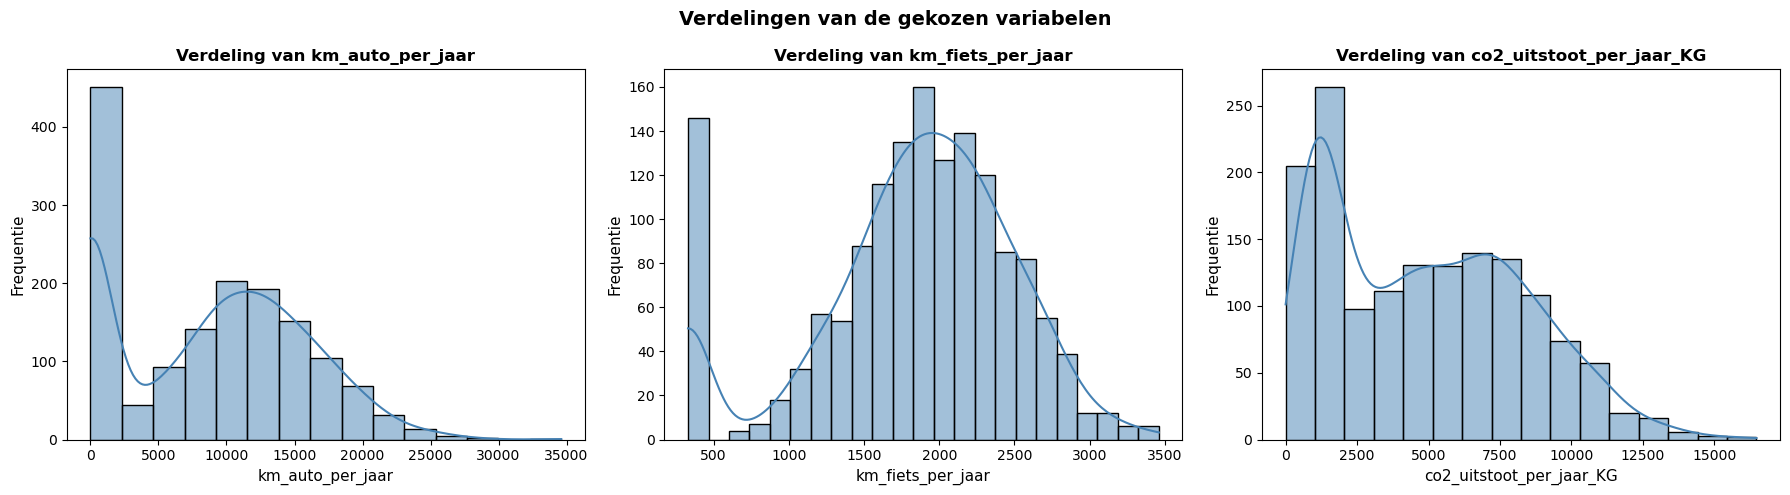

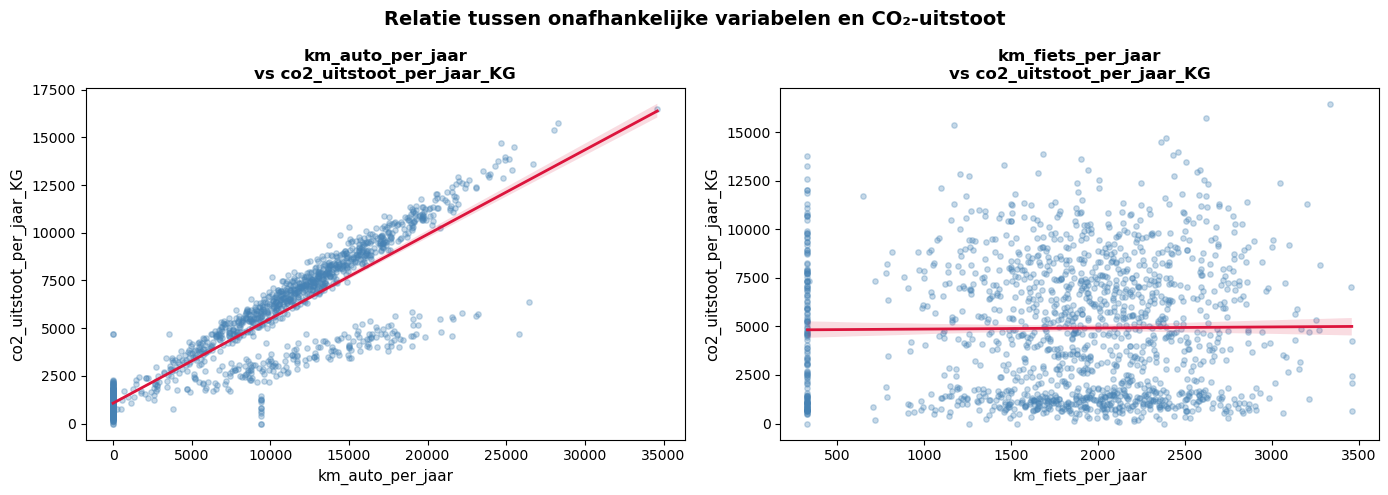

In [35]:
# Python: Kies 2 onafhankelijke variabelen waarvan je denkt dat het invloed kan hebben
# op de jaarlijkse CO2-uitstoot. Visualiseer de verdeling van deze twee variabelen
# en de verdeling van de afhankelijke variabele (CO2-uitstoot).
# Wij kiezen km_auto_per_jaar en km_fiets_per_jaar tegenover co2_uitstoot_per_jaar_KG.

gekozen_vars = ['km_auto_per_jaar', 'km_fiets_per_jaar']
target = 'co2_uitstoot_per_jaar_KG'
alle_vars = gekozen_vars + [target]

# ── Histogrammen ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, var in zip(axes, alle_vars):
    sns.histplot(df[var], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Verdeling van {var}', fontsize=12, fontweight='bold')
    ax.set_xlabel(var, fontsize=11)
    ax.set_ylabel('Frequentie', fontsize=11)

plt.suptitle('Verdelingen van de gekozen variabelen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Regplots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var in zip(axes, gekozen_vars):
    sns.regplot(data=df, x=var, y=target, ax=ax,
                scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
                line_kws={'color': 'crimson', 'linewidth': 2})
    ax.set_xlabel(var, fontsize=11)
    ax.set_ylabel(target, fontsize=11)
    ax.set_title(f'{var}\nvs {target}', fontsize=12, fontweight='bold')

plt.suptitle('Relatie tussen onafhankelijke variabelen en CO₂-uitstoot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
# Python: Toets, met behulp van statistiek, of de verdelingen normaal verdeeld zijn.
# Shapiro-Wilk toets voor alle numerieke kolommen (max 500 rijen vanwege gevoeligheid bij grote datasets)

numeric_cols = df.select_dtypes(include='number').columns.drop('persoon_ID', errors='ignore')

resultaten = []
for col in numeric_cols:
    steekproef = df[col].dropna().sample(min(500, len(df)), random_state=42)
    stat, p = stats.shapiro(steekproef)
    resultaten.append({
        'kolom': col,
        'Shapiro-W': round(stat, 4),
        'p-waarde': round(p, 4),
        'Normaal verdeeld': 'Ja' if p > 0.05 else 'Nee'
    })

shapiro_df = pd.DataFrame(resultaten).set_index('kolom')
display(shapiro_df)

,Shapiro-W,p-waarde,Normaal verdeeld
kolom,,,
leeftijd,0.9570,0.0000,Nee
gewicht_KG,0.9941,0.0482,Nee
jaarsalaris_eu,0.9942,0.0539,Ja
huishouden_grootte,0.8958,0.0000,Nee
km_auto_per_jaar,0.9075,0.0000,Nee
km_fiets_per_jaar,0.9434,0.0000,Nee
km_ov_per_jaar,0.9903,0.0023,Nee
km_vliegtuig_per_jaar,0.9666,0.0000,Nee
dagen_thuiswerken_per_week_pro_rato,0.9111,0.0000,Nee


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Preparatie van de Dataset

In dit hoofdstuk transformeren wij de data zodat deze in machine-learning gebruikt kan worden


</div>

In [6]:
# Python: Voer de transformatie uit.
# Let op dat je de getransformeerde variabelen in een nieuw dataframe opslaat,
# zodat je de oorspronkelijke waarden behoudt.

In [7]:
# Python: Zorg dat je inzicht krijgt in de relaties tussen alle variabelen.

<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Kansrekening

In dit hoofdstuk passen wij de regels van kansrekening toe op de dataset. Wij berekenen kansen op basis van de gegevens van de 1500 burgers en interpreteren de uitkomsten.


</div>

In [8]:
# Wat is de kans dat een willekeurig persoon 5000 KG CO2 uitstoot? Gebruik de standaard normaal verdeling in de berekening.


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Statistische Toets

In dit hoofdstuk kiezen wij een geschikte statistische toets op basis van de onderzoeksvraag en de aard van de data. Wij voeren de toets uit in Python en interpreteren de resultaten, inclusief de p-waarde en de conclusie ten aanzien van de hypothese.

</div>

In [9]:
# Python: Maak de geschikte plotjes om het verschil tussen de groepen te visualiseren.

In [10]:
# Python: Voer de statistische toets uit.

<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Lineaire Regressie

In dit hoofdstuk bouwen wij een lineair regressiemodel om de jaarlijkse CO₂-uitstoot te voorspellen. Wij splitsen de data in een train- en testset, trainen het model, bepalen de meest invloedrijke variabelen en vergelijken twee modellen met behulp van 20-fold cross-validatie en een statistische toets.

</div>

In [11]:
# Python: Split de data op in een train- en testset. Kies zelf voor een geschikte split.

In [12]:
# Python: Train een lineair regressiemodel om de jaarlijkse CO₂-uitstoot te voorspellen.

In [13]:
# Python: Bepaal welke 5 onafhankelijke variabelen de meeste invloed hebben op de voorspelling.

In [14]:
# Python: Train en test nu twee modellen:
# Model 1: met alle variabelen
# Model 2: met de vijf meest invloedrijke variabelen
# Gebruik hiervoor 20-fold cross-validatie.

In [15]:
# Python: Gebruik de gekozen metric om de nauwkeurigheid van beide modellen te kwantificeren.

In [16]:
# Python: Maak de geschikte plotjes om het verschil in nauwkeurigheid tussen de twee modellen te visualiseren.

In [17]:
# Python: Gebruik toetsende statistiek en de resultaten van de 20-fold cross-validatie
# om te onderzoeken welk model significant beter is.

<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Logistische Regressie

In dit hoofdstuk zetten wij de CO₂-uitstoot om naar een binaire klasse (lage vs. hoge uitstoot) en trainen wij een logistisch regressiemodel op de vijf meest invloedrijke variabelen.

</div>

In [18]:
# Python: Splits de target variabele op in 2 klassen van gelijke grootte.
# Kies hiervoor een geschikte afkapwaarde.
# Codeer de eerste groep als 0 (lage uitstoot) en de tweede groep als 1 (hoge uitstoot).

In [19]:
# Python: Train een nieuw model op de nieuwe target.
# Gebruik hierbij alleen de vijf meest invloedrijke onafhankelijke variabelen die je eerder hebt gekozen.

<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Conclusie

In dit hoofdstuk geven wij antwoord op de onderzoeksvraag op basis van de resultaten uit de vorige hoofdstukken. Wij bespreken in hoeverre onze hypothesen bevestigd of verworpen zijn en wat de bevindingen betekenen in de bredere context van CO₂-uitstoot en mobiliteitsgedrag.

</div>